[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/01_problem_formulation_and_convexity/first_principles.ipynb)

# Module 01 — Optimization Problem Formulation and Convexity

## 1. Why This Module Exists

### 1.1 One skeleton behind many questions

Nature and engineering are saturated with selection principles.
A hanging chain settles into the shape of least potential energy.
Light travels along the path of least time.
A neural network is trained by driving a loss function as low as possible over millions of parameters.
An airline schedules crews at minimum cost while respecting labor rules.

All of these share one skeleton: a set of *candidate decisions*, a *scalar criterion* ranking them, and *rules* separating the allowed from the forbidden.
Optimization is the mathematics of this skeleton.

The first task of the subject is not solving anything — it is learning to write the skeleton down precisely, because a problem well formulated is a problem half solved, and a problem badly formulated may be unsolvable in principle.

### 1.2 A universal language

Every optimization problem — scheduling, control, statistics, physics — can be written in one canonical shape:

$$
\min_{\mathbf{x} \in \mathcal{D}} f(\mathbf{x}) \quad \text{subject to} \quad g_i(\mathbf{x}) \le 0 \ (i = 1, \dots, m), \qquad h_j(\mathbf{x}) = 0 \ (j = 1, \dots, p)
$$

Nothing essential is lost by this normalization:

- A maximization $\max f$ becomes $-\min(-f)$ with the same optimizers.
- A constraint $g(\mathbf{x}) \ge c$ becomes $c - g(\mathbf{x}) \le 0$.
- A two-sided bound $a \le x \le b$ becomes two inequality constraints.
- An equality $h = c$ becomes $h - c = 0$.

The payoff of a single normal form is that every theorem, every solver interface, and every optimality certificate can be stated once.

### 1.3 What is at stake

Picture the graph of $f$ as a landscape over the feasible region; a minimizer is the lowest feasible point.
If the landscape is a single bowl, walking downhill from anywhere reaches the bottom.
If it is a mountain range with many basins, local descent gets trapped, and certifying that the deepest basin has been found may require examining exponentially many basins.

The property that separates the two situations is **convexity**, and the modern view is that the great divide in optimization is not linear versus nonlinear but convex versus non-convex.
This module builds the convexity toolkit from its two-point definition to the second-order Hessian test, and proves the theorem that makes the divide real: on a convex problem, every local minimum is global.

## 2. Intuition

A convex function is one fact seen from three sides.

**The chord picture.** Pick two points on the graph and stretch a straight segment between them. For a convex function the segment never dips below the graph; for a non-convex one it can. This is the two-point inequality, and it uses no derivatives at all — it applies to $\lvert x \rvert$ as much as to $x^2$.

**The tangent picture.** If the function is differentiable, its tangent plane at any point lies weakly below the entire graph. A convex function is therefore its own global lower bound estimator: local slope information at one point is a valid statement about every other point. This is exactly why local search cannot be fooled.

**The epigraph picture.** Fill in everything on or above the graph. The resulting solid — the epigraph — is a convex *set* precisely when the function is convex. Function convexity and set convexity are the same theorem twice, which is why the same closure rules (intersections, maxima) serve both.

The consequence is a change in what a local computation can certify. On a general landscape, a downhill step tells you only about the neighborhood you are standing in. On a convex landscape, the tangent picture converts that same step into a statement about the whole space: if no descent direction exists here, no better point exists anywhere.

**Environment.** The preamble below fixes plotting defaults, the random generator, and print precision for every code cell in this notebook. All randomness in this notebook flows through `rng`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

print("environment ready:", np.__version__)

environment ready: 2.4.6


The environment is fixed and reproducible: every number printed below can be regenerated exactly by running the notebook top to bottom.

**Figure 2.1.** The chord and tangent pictures side by side. Left: the convex $f(x) = x^2 + \tfrac{1}{2}$ with one chord (above the graph) and one tangent line (below it). Right: the non-convex $f(x) = x^4 - 2x^2 + x$, where the same chord construction cuts *below* the graph and two distinct basins exist.

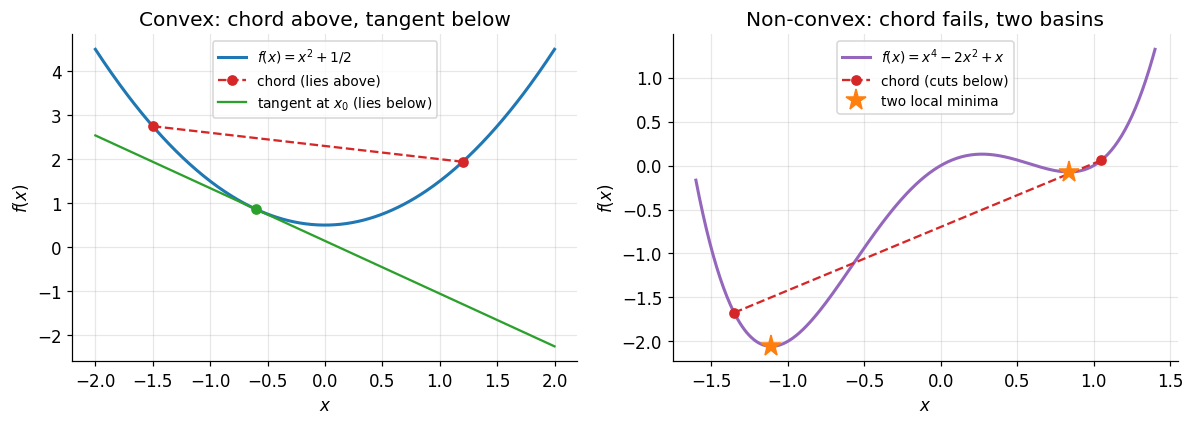

local minimizers of the right panel: [-1.1072  0.8376]
their objective values          : [-2.0562 -0.0733]


In [2]:
def f_convex(x):
    return x**2 + 0.5

def f_wells(x):
    return x**4 - 2.0 * x**2 + x

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

x = np.linspace(-2.0, 2.0, 400)
a, b = -1.5, 1.2
ax = axes[0]
ax.plot(x, f_convex(x), lw=2, label=r"$f(x)=x^2+1/2$")
ax.plot([a, b], [f_convex(a), f_convex(b)], "o--", color="tab:red",
        label="chord (lies above)")
x0 = -0.6
ax.plot(x, f_convex(x0) + 2 * x0 * (x - x0), color="tab:green",
        label="tangent at $x_0$ (lies below)")
ax.plot([x0], [f_convex(x0)], "o", color="tab:green")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Convex: chord above, tangent below")
ax.legend(loc="upper center", fontsize=9)

ax = axes[1]
xw = np.linspace(-1.6, 1.4, 400)
aw, bw = -1.35, 1.05
ax.plot(xw, f_wells(xw), lw=2, color="tab:purple", label=r"$f(x)=x^4-2x^2+x$")
ax.plot([aw, bw], [f_wells(aw), f_wells(bw)], "o--", color="tab:red",
        label="chord (cuts below)")
roots = np.sort(np.roots([4.0, 0.0, -4.0, 1.0]).real)
ax.plot(roots[[0, 2]], f_wells(roots[[0, 2]]), "*", ms=14, color="tab:orange",
        label="two local minima")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Non-convex: chord fails, two basins")
ax.legend(loc="upper center", fontsize=9)

fig.tight_layout()
plt.show()

print("local minimizers of the right panel:", roots[[0, 2]])
print("their objective values          :", f_wells(roots[[0, 2]]))

On the left the chord never touches the interior of the region below the graph and the tangent never rises above it — the two inequalities that Sections 3 and 4 turn into definitions and theorems. On the right the same constructions fail, and the printed values show two *unequal* basins: the minimizer near $x = 0.8376$ has value $-0.0733$, well above the global value $-2.0562$ near $x = -1.1072$. Local descent started on the right slope stops at a point that is not optimal.

## 3. Definitions

### Definition 3.1 (Standard-form optimization problem)

Let $\mathcal{D} \subseteq \mathbb{R}^n$ and let $f, g_1, \dots, g_m, h_1, \dots, h_p : \mathcal{D} \to \mathbb{R}$.
The **standard-form problem** is

$$
\min_{\mathbf{x} \in \mathcal{D}} f(\mathbf{x}) \quad \text{s.t.} \quad g_i(\mathbf{x}) \le 0, \quad h_j(\mathbf{x}) = 0
$$

Here $f$ is the **objective**, the $g_i$ are **inequality constraints**, the $h_j$ are **equality constraints**, and $\mathbf{x}$ is the **decision variable**.

### Definition 3.2 (Feasible set, optimal value, minimizer)

The **feasible set** is

$$
\mathcal{F} = \{\mathbf{x} \in \mathcal{D} \mid g_i(\mathbf{x}) \le 0 \ \forall i, \ h_j(\mathbf{x}) = 0 \ \forall j\}
$$

The **optimal value** is $p^{\star} = \inf\,\{f(\mathbf{x}) \mid \mathbf{x} \in \mathcal{F}\}$, with the conventions $p^{\star} = +\infty$ if $\mathcal{F} = \emptyset$ (infeasible problem) and $p^{\star} = -\infty$ if $f$ is unbounded below on $\mathcal{F}$.
A **minimizer** is any $\mathbf{x}^{\star} \in \mathcal{F}$ with $f(\mathbf{x}^{\star}) = p^{\star}$.
The infimum always exists in the extended reals; a minimizer need not.

### Definition 3.3 (Local and global minimizers)

A point $\mathbf{x}^{\star} \in \mathcal{F}$ is a **global minimizer** if $f(\mathbf{x}^{\star}) \le f(\mathbf{x})$ for all $\mathbf{x} \in \mathcal{F}$.
It is a **local minimizer** if there exists $\varepsilon \gt 0$ such that

$$
f(\mathbf{x}^{\star}) \le f(\mathbf{x}) \quad \text{for all } \mathbf{x} \in \mathcal{F} \text{ with } \lVert \mathbf{x} - \mathbf{x}^{\star}\rVert \lt \varepsilon
$$

Every global minimizer is local; the converse fails in general.

### Definition 3.4 (Taxonomy of optimization problems)

Problems are classified along four independent axes:

1. **Continuous vs discrete**: $\mathbf{x} \in \mathbb{R}^n$ versus $\mathbf{x} \in \mathbb{Z}^n$ (or mixed). Discrete feasible sets destroy gradients and convexity arguments.
2. **Convex vs non-convex**: convex objective and convex feasible set versus anything else.
3. **Smooth vs non-smooth**: $f \in \mathcal{C}^1$ or $\mathcal{C}^2$ versus functions with kinks such as $\lvert x\rvert$ or $\max$-type objectives.
4. **Unconstrained vs constrained**: $\mathcal{F} = \mathbb{R}^n$ versus explicit $g_i, h_j$.

A single problem occupies one cell of this $2 \times 2 \times 2 \times 2$ grid, and the algorithmic landscape differs radically between cells: least squares (continuous, convex, smooth, unconstrained) admits a closed form, while integer non-convex problems require branch-and-bound or heuristics.

### Definition 3.5 (Convex set)

A set $C \subseteq \mathbb{R}^n$ is **convex** if for all $\mathbf{x}, \mathbf{y} \in C$ and all $\theta \in [0, 1]$,

$$
\theta \mathbf{x} + (1 - \theta)\mathbf{y} \in C
$$

that is, $C$ contains the entire segment between any two of its points.

**Canonical convex sets.**

- **Hyperplane**: $\{\mathbf{x} \mid \mathbf{a}^\top\mathbf{x} = b\}$ with $\mathbf{a} \neq \mathbf{0}$.
- **Half-space**: $\{\mathbf{x} \mid \mathbf{a}^\top\mathbf{x} \le b\}$ — one side of a hyperplane.
- **Norm ball**: $\{\mathbf{x} \mid \lVert \mathbf{x} - \mathbf{c}\rVert \le r\}$ for any norm $\lVert \cdot \rVert$.
- **Polyhedron**: $\{\mathbf{x} \mid A\mathbf{x} \le \mathbf{b}, \ C\mathbf{x} = \mathbf{d}\}$ — a finite intersection of half-spaces and hyperplanes.
- **Positive semidefinite cone**: $\mathbb{S}^n_+ = \{X \in \mathbb{S}^n \mid X \succeq 0\}$, where $\mathbb{S}^n$ is the space of symmetric $n \times n$ matrices.

### Definition 3.6 (Convex function)

Let $C$ be a convex set. A function $f : C \to \mathbb{R}$ is **convex** if for all $\mathbf{x}, \mathbf{y} \in C$ and $\theta \in [0, 1]$,

$$
f(\theta \mathbf{x} + (1-\theta)\mathbf{y}) \le \theta f(\mathbf{x}) + (1-\theta) f(\mathbf{y})
$$

Geometrically: every chord of the graph lies on or above the graph.
$f$ is **concave** if $-f$ is convex.
The requirement that the domain $C$ be convex is part of the definition, not a technicality: the midpoint $\theta\mathbf{x} + (1-\theta)\mathbf{y}$ must be in the domain for the inequality to be meaningful.

### Definition 3.7 (Strict convexity)

$f$ is **strictly convex** if the inequality of Definition 3.6 is strict whenever $\mathbf{x} \neq \mathbf{y}$ and $\theta \in (0, 1)$.

### Definition 3.8 (Strong convexity)

$f$ is **$\mu$-strongly convex** ($\mu \gt 0$) if $f(\mathbf{x}) - \frac{\mu}{2}\lVert \mathbf{x}\rVert^2$ is convex; for $\mathcal{C}^2$ functions this is equivalent to $\nabla^2 f(\mathbf{x}) \succeq \mu I$ everywhere.
The implications

$$
\text{strongly convex} \implies \text{strictly convex} \implies \text{convex}
$$

are strict, with counterexamples $f(x) = x^4$ (strictly but not strongly convex, since $f''(0) = 0$) and $f(x) = x$ (convex but not strictly).

### Definition 3.9 (Epigraph)

The **epigraph** of $f : C \to \mathbb{R}$ is the region on or above its graph:

$$
\operatorname{epi} f = \{(\mathbf{x}, t) \in C \times \mathbb{R} \mid f(\mathbf{x}) \le t\}
$$

### Definition 3.10 (Sublevel set)

The **$\alpha$-sublevel set** of $f$ is $S_\alpha = \{\mathbf{x} \in C \mid f(\mathbf{x}) \le \alpha\}$.

## 4. Main Results

Each theorem is stated with its hypotheses inline, followed by one sentence per hypothesis explaining what fails without it. All proofs are in Section 5.

### Theorem 4.1 (Max-min equivalence)

For any function $f : \mathcal{F} \to \mathbb{R}$ on any nonempty set $\mathcal{F}$,

$$
\sup_{\mathbf{x} \in \mathcal{F}} f(\mathbf{x}) = -\inf_{\mathbf{x} \in \mathcal{F}} \big(-f(\mathbf{x})\big)
$$

and $\mathbf{x}^{\star}$ maximizes $f$ over $\mathcal{F}$ if and only if it minimizes $-f$ over $\mathcal{F}$.

*Hypotheses.* Nonemptiness only fixes the degenerate conventions $\sup \emptyset = -\infty$ and $\inf \emptyset = +\infty$; no continuity, convexity, or structure on $\mathcal{F}$ is used, which is why the reduction to minimization is universal.

### Theorem 4.2 (Epigraph characterization)

Let $C \subseteq \mathbb{R}^n$ be convex and $f : C \to \mathbb{R}$. Then $f$ is convex if and only if $\operatorname{epi} f$ is a convex subset of $\mathbb{R}^{n+1}$.

*Hypotheses.* Convexity of $C$ is needed because $\operatorname{epi} f$ projects onto $C$, and a set with non-convex shadow cannot itself be convex.

### Theorem 4.3 (Jensen's inequality, finite form)

Let $f$ be convex on a convex set $C$. For any $\mathbf{x}_1, \dots, \mathbf{x}_k \in C$ and weights $\theta_i \ge 0$ with $\sum_{i=1}^k \theta_i = 1$,

$$
f\!\left(\sum_{i=1}^k \theta_i \mathbf{x}_i\right) \le \sum_{i=1}^k \theta_i f(\mathbf{x}_i)
$$

*Hypotheses.* Convexity of $f$ supplies the two-point inequality that drives the induction; nonnegativity of the weights is what allows an inequality to be multiplied by $\theta_i$ without flipping; $\sum_i \theta_i = 1$ keeps the argument inside $C$, and without it the left side may not even be defined.

### Theorem 4.4 (First-order characterization)

Let $C \subseteq \mathbb{R}^n$ be open and convex and let $f : C \to \mathbb{R}$ be differentiable. Then $f$ is convex if and only if

$$
f(\mathbf{y}) \ge f(\mathbf{x}) + \nabla f(\mathbf{x})^\top(\mathbf{y} - \mathbf{x}) \quad \text{for all } \mathbf{x}, \mathbf{y} \in C
$$

*Hypotheses.* Differentiability is what makes $\nabla f$ exist at all — $\lvert x \rvert$ is convex with no tangent at $0$; openness guarantees the difference quotient can be taken from both sides at every point of $C$; convexity of $C$ keeps the segment from $\mathbf{x}$ to $\mathbf{y}$ inside the domain.

### Theorem 4.5 (Second-order characterization)

Let $C \subseteq \mathbb{R}^n$ be open and convex and let $f \in \mathcal{C}^2(C)$. Then

$$
f \text{ is convex} \iff \nabla^2 f(\mathbf{x}) \succeq 0 \ \text{ for all } \mathbf{x} \in C
$$

and $\nabla^2 f(\mathbf{x}) \succ 0$ everywhere implies strict convexity, though the converse fails ($f(x) = x^4$).

*Hypotheses.* Twice continuous differentiability is needed for Taylor's theorem with a Lagrange remainder; openness lets a small ball around each point be probed in every direction; convexity of $C$ is essential and not decorative — $f(x) = 1/x^2$ has $f''(x) = 6/x^4 \gt 0$ on the non-convex domain $\{x \neq 0\}$ yet is not convex there, since the chord from $-1$ to $1$ leaves the domain.

### Theorem 4.6 (Local minima are global — the headline theorem)

Let $\mathcal{F} \subseteq \mathbb{R}^n$ be convex and let $f : \mathcal{F} \to \mathbb{R}$ be convex. Then every local minimizer of $f$ over $\mathcal{F}$ is a global minimizer, and the set of minimizers $\operatorname{argmin}_{\mathcal{F}} f$ is convex.

*Hypotheses.* Convexity of $\mathcal{F}$ is what makes the segment toward a better point feasible; convexity of $f$ is what makes the objective decrease along that segment. Drop either one and the theorem is false: $f(x) = x^4 - 2x^2 + x$ on $\mathcal{F} = \mathbb{R}$ is a non-convex objective with a non-global local minimizer, while the convex $f(x) = x^2$ on the non-convex $\mathcal{F} = [-3,-1] \cup [2,3]$ has a local minimizer at $x = 2$ that is not global.

### Theorem 4.7 (Uniqueness under strict convexity)

Let $\mathcal{F}$ be convex and $f$ strictly convex on $\mathcal{F}$. Then $f$ has at most one global minimizer on $\mathcal{F}$.

*Hypotheses.* Strictness is exactly what forbids a flat bottom: the merely convex $f(x,y) = x^2$ is minimized along an entire line. Convexity of $\mathcal{F}$ makes the midpoint of two candidate minimizers feasible, which is where the contradiction is produced. Note the statement is "at most one": existence is a separate question.

### Theorem 4.8 (Convexity-preserving operations)

Let $C$ be convex.

1. If $f_1, \dots, f_k$ are convex on $C$ and $\alpha_i \ge 0$, then $\sum_i \alpha_i f_i$ is convex.
2. If $\{f_\alpha\}$ is any family of convex functions on $C$, then $f = \sup_\alpha f_\alpha$ is convex wherever it is finite.
3. If $\{C_\alpha\}$ is any family of convex sets, then $\bigcap_\alpha C_\alpha$ is convex.
4. If $g$ is convex on $C$ and $A\mathbf{x} + \mathbf{b}$ maps a convex set into $C$, then $\mathbf{x} \mapsto g(A\mathbf{x}+\mathbf{b})$ is convex.
5. If $g : C \to \mathbb{R}$ is convex and $h : \mathbb{R} \to \mathbb{R}$ is convex **and nondecreasing**, then $h \circ g$ is convex.

*Hypotheses.* Nonnegativity in (1) prevents a negated convex function from appearing; finiteness in (2) keeps the supremum a real-valued function; affineness in (4) is required because the composition argument needs $T(\theta\mathbf{x} + (1-\theta)\mathbf{y}) = \theta T(\mathbf{x}) + (1-\theta)T(\mathbf{y})$ exactly; monotonicity in (5) is indispensable, as the counterexample in Section 7 shows.

### Lemma 4.9 (Exact chord gap of a quadratic)

Let $Q \in \mathbb{S}^n$, $\mathbf{c} \in \mathbb{R}^n$, and $q(\mathbf{z}) = \frac{1}{2}\mathbf{z}^\top Q \mathbf{z} + \mathbf{c}^\top \mathbf{z}$. Then for all $\mathbf{x}, \mathbf{y} \in \mathbb{R}^n$ and $\theta \in [0,1]$,

$$
\theta q(\mathbf{x}) + (1-\theta) q(\mathbf{y}) - q\big(\theta\mathbf{x} + (1-\theta)\mathbf{y}\big) = \frac{1}{2}\,\theta(1-\theta)\,(\mathbf{x}-\mathbf{y})^\top Q\,(\mathbf{x}-\mathbf{y})
$$

*Hypotheses.* Symmetry of $Q$ makes the cross terms combine; no definiteness is assumed, which is what turns the identity into an exact convexity test for quadratics: $q$ is convex if and only if the right-hand side is nonnegative for every $\mathbf{x} - \mathbf{y}$, i.e. iff $Q \succeq 0$.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Let $S = \{f(\mathbf{x}) \mid \mathbf{x} \in \mathcal{F}\}$ and $-S = \{-s \mid s \in S\}$.
If $u$ is an upper bound for $S$ then $-u$ is a lower bound for $-S$, and conversely; the map $u \mapsto -u$ is an order-reversing bijection between the upper bounds of $S$ and the lower bounds of $-S$.
The least element of the second family is therefore the negative of the greatest element of the first, i.e. $\inf(-S) = -\sup S$, which is the displayed identity.
For the optimizer statement, $f(\mathbf{x}^{\star}) \ge f(\mathbf{x})$ for all feasible $\mathbf{x}$ holds if and only if $-f(\mathbf{x}^{\star}) \le -f(\mathbf{x})$ for all feasible $\mathbf{x}$.

$$
\boxed{\sup_{\mathcal{F}} f = -\inf_{\mathcal{F}} (-f), \qquad \operatorname{argmax}_{\mathcal{F}} f = \operatorname{argmin}_{\mathcal{F}} (-f)}
$$

**Interpretation.** Maximization carries no separate theory: it is minimization read through a mirror, and the mirror moves the optimal *value* but never the optimal *point*. Every later theorem about minimizing convex functions therefore doubles as a theorem about maximizing concave functions, which is how maximum-likelihood and maximum-entropy problems enter convex optimization unchanged.

### Proof 5.2 (of Theorem 4.2)

($\Rightarrow$) Let $f$ be convex and take $(\mathbf{x}, t_1), (\mathbf{y}, t_2) \in \operatorname{epi} f$, so $f(\mathbf{x}) \le t_1$ and $f(\mathbf{y}) \le t_2$. For $\theta \in [0,1]$ the point $\theta\mathbf{x} + (1-\theta)\mathbf{y}$ lies in $C$ because $C$ is convex, and

$$
f(\theta\mathbf{x} + (1-\theta)\mathbf{y}) \le \theta f(\mathbf{x}) + (1-\theta) f(\mathbf{y}) \le \theta t_1 + (1-\theta) t_2
$$

so $\theta(\mathbf{x},t_1) + (1-\theta)(\mathbf{y},t_2) \in \operatorname{epi} f$.

($\Leftarrow$) Let $\operatorname{epi} f$ be convex and take $\mathbf{x}, \mathbf{y} \in C$. The points $(\mathbf{x}, f(\mathbf{x}))$ and $(\mathbf{y}, f(\mathbf{y}))$ lie in $\operatorname{epi} f$, hence so does their combination $\big(\theta\mathbf{x}+(1-\theta)\mathbf{y},\ \theta f(\mathbf{x}) + (1-\theta) f(\mathbf{y})\big)$. Membership in the epigraph says precisely

$$
f(\theta\mathbf{x} + (1-\theta)\mathbf{y}) \le \theta f(\mathbf{x}) + (1-\theta) f(\mathbf{y})
$$

which is Definition 3.6.

$$
\boxed{f \text{ convex} \iff \operatorname{epi} f \text{ convex}}
$$

**Interpretation.** Function convexity and set convexity are the same statement in different coordinates. The practical consequence is that every closure rule for sets transfers to functions and back: intersecting epigraphs is taking pointwise maxima, and projecting an epigraph is partial minimization.

### Proof 5.3 (of Theorem 4.3, Jensen)

By induction on the number of points $k$.

**Step 1 (base case $k = 2$).** The statement $f(\theta_1 \mathbf{x}_1 + \theta_2 \mathbf{x}_2) \le \theta_1 f(\mathbf{x}_1) + \theta_2 f(\mathbf{x}_2)$ with $\theta_2 = 1 - \theta_1$ is exactly Definition 3.6.

**Step 2 (inductive hypothesis).** Assume the claim for any $k-1$ points and weights.

**Step 3 (inductive step).** Take $k$ points with weights $\theta_1, \dots, \theta_k$. If $\theta_k = 1$ the claim is trivial, so assume $\theta_k \lt 1$ and set $\lambda_i = \frac{\theta_i}{1-\theta_k}$ for $i \le k-1$. These are nonnegative and sum to $1$ because $\sum_{i=1}^{k-1}\theta_i = 1 - \theta_k$. Write

$$
\sum_{i=1}^{k} \theta_i \mathbf{x}_i = (1 - \theta_k)\,\mathbf{z} + \theta_k \mathbf{x}_k, \qquad \mathbf{z} = \sum_{i=1}^{k-1} \lambda_i \mathbf{x}_i
$$

The point $\mathbf{z}$ lies in $C$: a convex set contains all convex combinations of its points, itself an induction whose base case is Definition 3.5.

**Step 4 (apply the definition, then the hypothesis).** The two-point inequality at $\mathbf{z}$ and $\mathbf{x}_k$ gives

$$
f\!\left(\sum_{i=1}^{k}\theta_i \mathbf{x}_i\right) \le (1-\theta_k) f(\mathbf{z}) + \theta_k f(\mathbf{x}_k)
$$

The inductive hypothesis gives $f(\mathbf{z}) \le \sum_{i=1}^{k-1}\lambda_i f(\mathbf{x}_i)$. Substituting and using $(1-\theta_k)\lambda_i = \theta_i$ completes the induction.

$$
\boxed{f\!\left(\sum_{i=1}^{k}\theta_i \mathbf{x}_i\right) \le \sum_{i=1}^{k}\theta_i f(\mathbf{x}_i) \quad \text{for all convex weights } \theta}
$$

**Interpretation.** Convexity is a two-point statement that automatically upgrades to any finite number of points, and — by approximating a distribution with finitely supported ones — to $f(\mathbb{E}[X]) \le \mathbb{E}[f(X)]$. Every inequality of the form "the value at the average is below the average of the values" is this one theorem, which is why AM-GM, Gibbs' inequality, and the nonnegativity of KL divergence all reduce to it.

### Proof 5.4 (of Theorem 4.4, both directions)

**Direction 1 (convexity $\implies$ tangent underestimator).**
Fix $\mathbf{x}, \mathbf{y} \in C$ and $\theta \in (0, 1]$. Convexity at $\mathbf{x} + \theta(\mathbf{y}-\mathbf{x}) = (1-\theta)\mathbf{x} + \theta\mathbf{y}$ gives

$$
f(\mathbf{x} + \theta(\mathbf{y}-\mathbf{x})) \le (1-\theta) f(\mathbf{x}) + \theta f(\mathbf{y})
$$

Subtract $f(\mathbf{x})$ and divide by $\theta \gt 0$:

$$
\frac{f(\mathbf{x} + \theta(\mathbf{y}-\mathbf{x})) - f(\mathbf{x})}{\theta} \le f(\mathbf{y}) - f(\mathbf{x})
$$

As $\theta \to 0^+$ the left side converges to the directional derivative $\nabla f(\mathbf{x})^\top(\mathbf{y}-\mathbf{x})$ by differentiability, and limits preserve non-strict inequalities, so $\nabla f(\mathbf{x})^\top(\mathbf{y}-\mathbf{x}) \le f(\mathbf{y}) - f(\mathbf{x})$.

**Direction 2 (tangent underestimator $\implies$ convexity).**
Fix $\mathbf{x}, \mathbf{y} \in C$, $\theta \in [0,1]$, and set $\mathbf{z} = \theta\mathbf{x} + (1-\theta)\mathbf{y} \in C$. Apply the hypothesis twice, anchored at $\mathbf{z}$:

$$
f(\mathbf{x}) \ge f(\mathbf{z}) + \nabla f(\mathbf{z})^\top(\mathbf{x}-\mathbf{z}), \qquad f(\mathbf{y}) \ge f(\mathbf{z}) + \nabla f(\mathbf{z})^\top(\mathbf{y}-\mathbf{z})
$$

Multiply the first by $\theta \ge 0$, the second by $1-\theta \ge 0$, and add:

$$
\theta f(\mathbf{x}) + (1-\theta) f(\mathbf{y}) \ge f(\mathbf{z}) + \nabla f(\mathbf{z})^\top\big(\theta\mathbf{x} + (1-\theta)\mathbf{y} - \mathbf{z}\big) = f(\mathbf{z})
$$

since the bracketed vector is $\mathbf{z} - \mathbf{z} = \mathbf{0}$. This is Definition 3.6.

$$
\boxed{f \text{ convex} \iff f(\mathbf{y}) \ge f(\mathbf{x}) + \nabla f(\mathbf{x})^\top(\mathbf{y}-\mathbf{x}) \ \ \forall\, \mathbf{x},\mathbf{y} \in C}
$$

**Interpretation.** For a convex function the tangent plane at a single point is a valid global lower bound on the entire function. The consequence is decisive for algorithms: if $\nabla f(\mathbf{x}) = \mathbf{0}$ then the bound reads $f(\mathbf{y}) \ge f(\mathbf{x})$ for every $\mathbf{y}$, so stationarity alone certifies global optimality — no search of the rest of the space is required.

### Proof 5.5 (of Theorem 4.5, both directions)

**Direction 1 (PSD Hessian $\implies$ convex).**
Fix $\mathbf{x}, \mathbf{y} \in C$. The segment between them lies in $C$ because $C$ is convex, so Taylor's theorem with Lagrange remainder supplies $\boldsymbol{\xi} = \mathbf{x} + t(\mathbf{y}-\mathbf{x})$ with $t \in (0,1)$ and

$$
f(\mathbf{y}) = f(\mathbf{x}) + \nabla f(\mathbf{x})^\top(\mathbf{y}-\mathbf{x}) + \frac{1}{2}(\mathbf{y}-\mathbf{x})^\top \nabla^2 f(\boldsymbol{\xi})(\mathbf{y}-\mathbf{x})
$$

Since $\nabla^2 f(\boldsymbol{\xi}) \succeq 0$, the remainder is nonnegative, so $f(\mathbf{y}) \ge f(\mathbf{x}) + \nabla f(\mathbf{x})^\top(\mathbf{y}-\mathbf{x})$ for all pairs, and Theorem 4.4 (Direction 2, proved above without reference to second derivatives) gives convexity.

**Direction 2 (convex $\implies$ PSD Hessian).**
Suppose $\nabla^2 f(\mathbf{x}_0)$ had a negative eigenvalue $\lambda \lt 0$ with unit eigenvector $\mathbf{v}$ at some $\mathbf{x}_0 \in C$. Since $C$ is open, $\varphi(t) = f(\mathbf{x}_0 + t\mathbf{v})$ is defined for small $\lvert t\rvert$, and $\varphi''(0) = \mathbf{v}^\top\nabla^2 f(\mathbf{x}_0)\mathbf{v} = \lambda$. Taylor's theorem for $\varphi$ gives

$$
f(\mathbf{x}_0 + t\mathbf{v}) = f(\mathbf{x}_0) + t\,\nabla f(\mathbf{x}_0)^\top\mathbf{v} + \frac{\lambda}{2}t^2 + o(t^2)
$$

Choose $t \neq 0$ small enough that the $o(t^2)$ term is bounded by $\frac{\lvert\lambda\rvert}{4}t^2$ in absolute value. Then

$$
f(\mathbf{x}_0 + t\mathbf{v}) \le f(\mathbf{x}_0) + t\,\nabla f(\mathbf{x}_0)^\top\mathbf{v} - \frac{\lvert\lambda\rvert}{4}t^2 \lt f(\mathbf{x}_0) + \nabla f(\mathbf{x}_0)^\top(t\mathbf{v})
$$

contradicting the tangent-underestimator inequality that Direction 1 of Theorem 4.4 forces on every convex differentiable function. Hence $\nabla^2 f \succeq 0$ throughout $C$.

**Remark (strictness).** If $\nabla^2 f \succ 0$ everywhere then the Taylor remainder above is strictly positive for $\mathbf{y} \neq \mathbf{x}$, so the tangent inequality is strict, which forces the chord inequality to be strict as well. The converse fails: $f(x) = x^4$ is strictly convex with $f''(0) = 0$.

$$
\boxed{f \in \mathcal{C}^2 \text{ on open convex } C: \quad f \text{ convex} \iff \nabla^2 f(\mathbf{x}) \succeq 0 \ \ \forall\,\mathbf{x} \in C}
$$

**Interpretation.** Convexity, an infinite family of two-point inequalities, collapses to a pointwise algebraic test on a symmetric matrix. The consequence is that certifying convexity becomes an eigenvalue computation, which is what makes the check mechanical for the quadratic models used in least squares, ridge regression, and Newton-type methods.

### Proof 5.6 (of Theorem 4.6, the headline theorem)

**Step 1 (set up a contradiction).** Let $\mathbf{x}^{\star}$ be a local minimizer, so there is $\varepsilon \gt 0$ with $f(\mathbf{x}^{\star}) \le f(\mathbf{x})$ for every feasible $\mathbf{x}$ satisfying $\lVert \mathbf{x}-\mathbf{x}^{\star}\rVert \lt \varepsilon$. Suppose it is not global: there is $\mathbf{y} \in \mathcal{F}$ with $f(\mathbf{y}) \lt f(\mathbf{x}^{\star})$. In particular $\mathbf{y} \neq \mathbf{x}^{\star}$, so $\lVert \mathbf{y}-\mathbf{x}^{\star}\rVert \gt 0$.

**Step 2 (walk along the segment).** For $\theta \in (0,1]$ put $\mathbf{z}_\theta = (1-\theta)\mathbf{x}^{\star} + \theta\mathbf{y}$. Convexity of $\mathcal{F}$ makes every $\mathbf{z}_\theta$ feasible, and convexity of $f$ gives

$$
f(\mathbf{z}_\theta) \le (1-\theta) f(\mathbf{x}^{\star}) + \theta f(\mathbf{y}) \lt (1-\theta) f(\mathbf{x}^{\star}) + \theta f(\mathbf{x}^{\star}) = f(\mathbf{x}^{\star})
$$

the strict step using $f(\mathbf{y}) \lt f(\mathbf{x}^{\star})$ together with $\theta \gt 0$.

**Step 3 (enter the local ball).** Choose

$$
\theta = \min\!\left(1, \ \frac{\varepsilon}{2\lVert \mathbf{y}-\mathbf{x}^{\star}\rVert}\right) \in (0,1] \implies \lVert \mathbf{z}_\theta - \mathbf{x}^{\star}\rVert = \theta\,\lVert \mathbf{y}-\mathbf{x}^{\star}\rVert \le \frac{\varepsilon}{2} \lt \varepsilon
$$

So $\mathbf{z}_\theta$ is feasible, lies inside the $\varepsilon$-ball, and has strictly smaller objective value than $\mathbf{x}^{\star}$ — contradicting local minimality. Hence no such $\mathbf{y}$ exists and $\mathbf{x}^{\star}$ is global.

**Step 4 (the minimizer set is convex).** If $\mathbf{x}_1, \mathbf{x}_2$ are both global minimizers with value $p^{\star}$ and $\theta \in [0,1]$, then $\theta\mathbf{x}_1 + (1-\theta)\mathbf{x}_2$ is feasible and $f(\theta\mathbf{x}_1 + (1-\theta)\mathbf{x}_2) \le \theta p^{\star} + (1-\theta)p^{\star} = p^{\star}$. It cannot be smaller than $p^{\star}$ by definition of the infimum, so equality holds and the combination is again a minimizer.

$$
\boxed{f \text{ convex on convex } \mathcal{F} \implies \text{every local minimizer is global, and } \operatorname{argmin}_{\mathcal{F}} f \text{ is convex}}
$$

**Interpretation.** The proof uses nothing but the segment: convexity of $\mathcal{F}$ makes the shortcut to a better point admissible, and convexity of $f$ makes the objective fall the whole way along it, so a strictly better point always has strictly better *neighbors* of $\mathbf{x}^{\star}$. The consequence is the entire practical value of convexity: a local certificate — no descent direction here — is a global certificate, and an algorithm may stop as soon as it finds one.

### Proof 5.7 (of Theorem 4.7)

**Step 1.** Suppose $\mathbf{x}_1 \neq \mathbf{x}_2$ are both global minimizers, so $f(\mathbf{x}_1) = f(\mathbf{x}_2) = p^{\star}$.

**Step 2.** Let $\mathbf{m} = \frac{1}{2}\mathbf{x}_1 + \frac{1}{2}\mathbf{x}_2$, which is feasible because $\mathcal{F}$ is convex. Strict convexity with $\theta = \frac{1}{2}$ and $\mathbf{x}_1 \neq \mathbf{x}_2$ gives the strict inequality

$$
f(\mathbf{m}) \lt \tfrac{1}{2}f(\mathbf{x}_1) + \tfrac{1}{2}f(\mathbf{x}_2) = p^{\star}
$$

**Step 3.** A feasible point with value below $p^{\star} = \inf_{\mathcal{F}} f$ is impossible. Hence $\mathbf{x}_1 = \mathbf{x}_2$.

$$
\boxed{f \text{ strictly convex on convex } \mathcal{F} \implies \text{at most one global minimizer}}
$$

**Interpretation.** Strict convexity removes flat bottoms, collapsing the convex minimizer set of Theorem 4.6 to a single point or the empty set. The consequence in modeling is identifiability: a strictly convex training objective has one answer, so two runs of a correct solver must agree, while a merely convex objective may have a whole subspace of equally optimal parameters.

### Proof 5.8 (of Theorem 4.8)

**(1) Nonnegative combinations.** For $\alpha_i \ge 0$, multiplying each chord inequality $f_i(\theta\mathbf{x}+(1-\theta)\mathbf{y}) \le \theta f_i(\mathbf{x}) + (1-\theta) f_i(\mathbf{y})$ by $\alpha_i$ preserves its direction; summing over $i$ gives the chord inequality for $\sum_i \alpha_i f_i$.

**(2) Pointwise supremum.** Write $f = \sup_\alpha f_\alpha$ and fix $\mathbf{x}, \mathbf{y} \in C$, $\theta \in [0,1]$. For each $\alpha$,

$$
f_\alpha(\theta\mathbf{x} + (1-\theta)\mathbf{y}) \le \theta f_\alpha(\mathbf{x}) + (1-\theta) f_\alpha(\mathbf{y}) \le \theta f(\mathbf{x}) + (1-\theta) f(\mathbf{y})
$$

using $f_\alpha \le f$ and $\theta, 1-\theta \ge 0$. The right-hand side does not depend on $\alpha$, so it bounds the supremum of the left-hand side, which is $f(\theta\mathbf{x}+(1-\theta)\mathbf{y})$.

**(3) Intersections.** If $\mathbf{x}, \mathbf{y} \in \bigcap_\alpha C_\alpha$ then for each $\alpha$ both points lie in $C_\alpha$, so $\theta\mathbf{x} + (1-\theta)\mathbf{y} \in C_\alpha$; as this holds for every $\alpha$, the combination lies in the intersection.

**(4) Affine precomposition.** Let $T(\mathbf{x}) = A\mathbf{x}+\mathbf{b}$. Affineness gives $T(\theta\mathbf{x}+(1-\theta)\mathbf{y}) = \theta T(\mathbf{x}) + (1-\theta)T(\mathbf{y})$ exactly, so

$$
g\big(T(\theta\mathbf{x}+(1-\theta)\mathbf{y})\big) = g\big(\theta T(\mathbf{x}) + (1-\theta)T(\mathbf{y})\big) \le \theta\, g(T(\mathbf{x})) + (1-\theta)\, g(T(\mathbf{y}))
$$

**(5) Scalar composition.** Convexity of $g$ gives $g(\theta\mathbf{x} + (1-\theta)\mathbf{y}) \le \theta g(\mathbf{x}) + (1-\theta)g(\mathbf{y})$. Because $h$ is nondecreasing, applying $h$ to both sides preserves the inequality, and then convexity of $h$ at the two scalars $g(\mathbf{x}), g(\mathbf{y})$ finishes it:

$$
h\big(g(\theta \mathbf{x} + (1-\theta)\mathbf{y})\big) \le h\big(\theta g(\mathbf{x}) + (1-\theta) g(\mathbf{y})\big) \le \theta\, h(g(\mathbf{x})) + (1-\theta)\, h(g(\mathbf{y}))
$$

Monotonicity is used exactly once, in the first inequality, and Section 7 exhibits the failure when it is dropped.

$$
\boxed{\textstyle\sum_i \alpha_i f_i,\ \ \sup_\alpha f_\alpha,\ \ \bigcap_\alpha C_\alpha,\ \ g(A\mathbf{x}+\mathbf{b}),\ \ h \circ g \ (h \text{ convex nondecreasing}) \ \text{ are all convex}}
$$

**Interpretation.** Convexity is compositional: it can be certified by parsing an expression tree instead of computing a Hessian. The consequence is disciplined convex programming — the elastic-net objective $\frac{1}{2}\lVert A\mathbf{x}-\mathbf{b}\rVert_2^2 + \lambda_1\lVert\mathbf{x}\rVert_1 + \frac{\lambda_2}{2}\lVert\mathbf{x}\rVert_2^2$ is certified convex by rules (1) and (4) alone, even though the $\ell_1$ term has no Hessian anywhere on the coordinate hyperplanes.

### Proof 5.9 (of Lemma 4.9)

The linear part is affine, so it cancels exactly: $\theta\,\mathbf{c}^\top\mathbf{x} + (1-\theta)\,\mathbf{c}^\top\mathbf{y} - \mathbf{c}^\top(\theta\mathbf{x}+(1-\theta)\mathbf{y}) = 0$. For the quadratic part write $a = \mathbf{x}^\top Q\mathbf{x}$, $b = \mathbf{y}^\top Q\mathbf{y}$, $c = \mathbf{x}^\top Q\mathbf{y}$, which is legitimate because $Q = Q^\top$ makes $\mathbf{y}^\top Q \mathbf{x} = c$ as well. Then

$$
\tfrac{\theta}{2} a + \tfrac{1-\theta}{2} b - \tfrac{1}{2}\big(\theta^2 a + (1-\theta)^2 b + 2\theta(1-\theta) c\big) = \tfrac{1}{2}\theta(1-\theta)\,(a + b - 2c)
$$

using $\theta - \theta^2 = \theta(1-\theta)$ and $(1-\theta) - (1-\theta)^2 = \theta(1-\theta)$. Finally $a + b - 2c = (\mathbf{x}-\mathbf{y})^\top Q(\mathbf{x}-\mathbf{y})$.

$$
\boxed{\theta q(\mathbf{x}) + (1-\theta) q(\mathbf{y}) - q(\theta\mathbf{x} + (1-\theta)\mathbf{y}) = \tfrac{1}{2}\theta(1-\theta)(\mathbf{x}-\mathbf{y})^\top Q(\mathbf{x}-\mathbf{y})}
$$

**Interpretation.** For quadratics the chord gap is not merely nonnegative but known in closed form, so the qualitative statement "convex" is upgraded to an exact quantity. The consequence is a machine-checkable identity: Example 6.1 uses it to verify the convexity machinery numerically to machine precision, and setting $\theta \to 0$ recovers the exact second-order expansion used in Example 6.4.

## 6. Worked Examples

Each example is computed by hand first on a deliberately small object, then recomputed in code that asserts agreement with the hand arithmetic.

### Example 6.1 (Hessian test on a $2 \times 2$ — Theorems 4.5, 4.7 and Lemma 4.9)

Take $f(x, y) = x^2 + xy + y^2$ on $\mathbb{R}^2$. Writing $\mathbf{z} = (x,y)$ gives $f(\mathbf{z}) = \frac{1}{2}\mathbf{z}^\top Q \mathbf{z}$ with

$$
Q = \nabla^2 f = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}
$$

**Step 1 (eigenvalues by hand).** The characteristic polynomial is $\det(Q - \lambda I) = (2-\lambda)^2 - 1 = \lambda^2 - 4\lambda + 3 = (\lambda-1)(\lambda-3)$, so $\lambda \in \{1, 3\}$, with eigenvector $(1,-1)$ for $\lambda = 1$ and $(1,1)$ for $\lambda = 3$.

**Step 2 (classify).** Both eigenvalues are positive, so $Q \succ 0$ and $f$ is strictly convex by Theorem 4.5, hence has at most one minimizer by Theorem 4.7. The sharp strong-convexity modulus is $\mu = \lambda_{\min} = 1$, witnessed by the direction $(1,-1)$.

**Step 3 (an exact chord gap).** Take $\mathbf{x} = (1,0)$, $\mathbf{y} = (-1,2)$, $\theta = \frac{1}{2}$. Then $f(\mathbf{x}) = 1$, $f(\mathbf{y}) = 1 - 2 + 4 = 3$, and the midpoint is $(0,1)$ with $f = 1$. The chord gap is $\frac{1}{2}(1) + \frac{1}{2}(3) - 1 = 1$. Lemma 4.9 predicts $\frac{1}{2}\cdot\frac{1}{4}\cdot(\mathbf{x}-\mathbf{y})^\top Q(\mathbf{x}-\mathbf{y})$ with $\mathbf{x}-\mathbf{y} = (2,-2)$ and $Q(2,-2) = (2,-2)$, i.e. $\frac{1}{8}\cdot 8 = 1$. The two agree.

**What the next cell checks.** That $\operatorname{eig}(Q) = \{1,3\}$, that the hand-computed chord gap equals $1$, and — the identity residual — that Lemma 4.9 holds to machine precision over $2000$ random triples $(\mathbf{x}, \mathbf{y}, \theta)$.

In [3]:
Q = np.array([[2.0, 1.0], [1.0, 2.0]])
c_lin = np.zeros(2)

def q_form(z):
    return 0.5 * z @ Q @ z + c_lin @ z

eigvals = np.linalg.eigvalsh(Q)
print("Hessian of f(x,y) = x^2 + xy + y^2:")
print(Q)
print(f"eigenvalues            : {eigvals}   (hand: 1 and 3)")
print(f"sharp strong-convexity mu = lambda_min = {eigvals[0]:.6f}")
assert np.allclose(eigvals, [1.0, 3.0])

x_hand, y_hand, th_hand = np.array([1.0, 0.0]), np.array([-1.0, 2.0]), 0.5
gap_hand = th_hand * q_form(x_hand) + (1 - th_hand) * q_form(y_hand) \
    - q_form(th_hand * x_hand + (1 - th_hand) * y_hand)
print(f"\nhand chord gap at x=(1,0), y=(-1,2), theta=1/2 : {gap_hand:.6f}   (hand: 1)")
assert abs(gap_hand - 1.0) < 1e-12

Xs = rng.uniform(-5, 5, size=(2000, 2))
Ys = rng.uniform(-5, 5, size=(2000, 2))
Ths = rng.uniform(0, 1, size=2000)
lhs = np.array([t * q_form(a) + (1 - t) * q_form(b) - q_form(t * a + (1 - t) * b)
                for a, b, t in zip(Xs, Ys, Ths)])
rhs = np.array([0.5 * t * (1 - t) * (a - b) @ Q @ (a - b)
                for a, b, t in zip(Xs, Ys, Ths)])
residual = np.max(np.abs(lhs - rhs))
print(f"max |chord gap - Lemma 4.9 formula| over 2000 triples : {residual:.3e}")
assert residual < 1e-10
print(f"minimum chord gap observed                            : {lhs.min():.6f}  (>= 0 as Q is PSD)")

Hessian of f(x,y) = x^2 + xy + y^2:
[[2. 1.]
 [1. 2.]]
eigenvalues            : [1. 3.]   (hand: 1 and 3)
sharp strong-convexity mu = lambda_min = 1.000000

hand chord gap at x=(1,0), y=(-1,2), theta=1/2 : 1.000000   (hand: 1)
max |chord gap - Lemma 4.9 formula| over 2000 triples : 2.132e-14
minimum chord gap observed                            : 0.000223  (>= 0 as Q is PSD)


The eigenvalues match the hand factorization exactly, the single hand-computed chord gap reproduces to $10^{-12}$, and the identity of Lemma 4.9 holds with a maximum residual of order $10^{-14}$ across $2000$ triples — machine-epsilon level for numbers of size $10$ to $100$, i.e. the identity is exact and only floating-point rounding separates the two sides. Every sampled chord gap is nonnegative, which is Definition 3.6 holding for this $f$.

### Example 6.2 (The epigraph of $\lvert x \rvert$ — Theorem 4.2)

For $f(x) = \lvert x \rvert$ on $\mathbb{R}$, Definition 3.9 gives

$$
\operatorname{epi} f = \{(x,t) \mid \lvert x \rvert \le t\} = \{(x,t) \mid x - t \le 0\} \cap \{(x,t) \mid -x - t \le 0\}
$$

**Step 1 (identify the set).** It is the intersection of two half-spaces in $\mathbb{R}^2$, hence a polyhedron, and it is closed under nonnegative scaling, hence a polyhedral cone.

**Step 2 (three sample points, by hand).** $(0.5, 1)$: $\lvert 0.5\rvert = 0.5 \le 1$, inside. $(-2, 2)$: $\lvert -2 \rvert = 2 = t$, on the boundary. $(3, 1)$: $\lvert 3 \rvert = 3 \gt 1$, outside.

**Step 3 (convexity by hand).** The midpoint of the two boundary points $(-2,2)$ and $(3,3)$ is $(0.5, 2.5)$, and $\lvert 0.5 \rvert = 0.5 \le 2.5$: the segment stays in the set. By Theorem 4.2 the convexity of this set is exactly the convexity of $\lvert x \rvert$, which Theorem 4.8(2) also gives as $\max(x, -x)$.

**What the next cell checks.** The three membership verdicts above, the midpoint claim, and a $2000$-sample search for any pair of points in the set whose midpoint escapes it. Figure 6.1 draws the cone.

epi|x| membership, |x| <= t :
  (  0.5,  1.0) : |x| = 0.50  ->  True
  ( -2.0,  2.0) : |x| = 2.00  ->  True
  (  3.0,  1.0) : |x| = 3.00  ->  False

midpoint of (-2,2) and (3,3) : (0.50, 2.50)  in set: True
midpoints escaping epi|x| out of 2000 random in-set pairs : 0


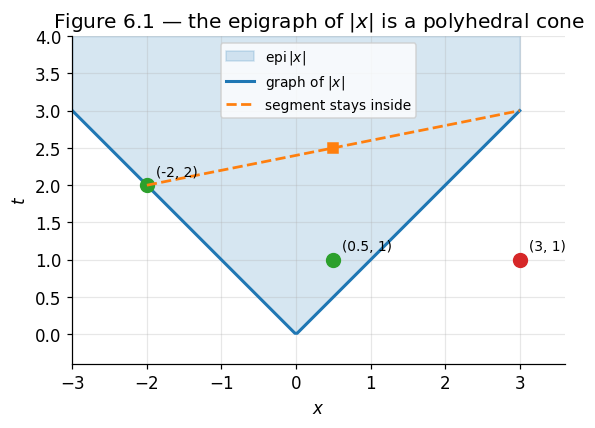

In [4]:
def in_epi_abs(x, t, tol=1e-12):
    return (x - t <= tol) and (-x - t <= tol)

samples = [(0.5, 1.0, True), (-2.0, 2.0, True), (3.0, 1.0, False)]
print("epi|x| membership, |x| <= t :")
for x_s, t_s, expected in samples:
    got = in_epi_abs(x_s, t_s)
    print(f"  ({x_s:>5}, {t_s:>4}) : |x| = {abs(x_s):.2f}  ->  {got}")
    assert got == expected

mid = (0.5 * np.array([-2.0, 2.0]) + 0.5 * np.array([3.0, 3.0]))
print(f"\nmidpoint of (-2,2) and (3,3) : ({mid[0]:.2f}, {mid[1]:.2f})  in set: {in_epi_abs(*mid)}")
assert in_epi_abs(*mid)

pa = rng.uniform(-3, 3, size=(2000, 2)); pa[:, 1] = np.abs(pa[:, 0]) + rng.uniform(0, 3, size=2000)
pb = rng.uniform(-3, 3, size=(2000, 2)); pb[:, 1] = np.abs(pb[:, 0]) + rng.uniform(0, 3, size=2000)
mids = 0.5 * (pa + pb)
escapes = int(np.sum(np.abs(mids[:, 0]) > mids[:, 1] + 1e-12))
print(f"midpoints escaping epi|x| out of 2000 random in-set pairs : {escapes}")
assert escapes == 0

fig, ax = plt.subplots(figsize=(5.4, 4.4))
xs_line = np.linspace(-3, 3, 200)
ax.fill_between(xs_line, np.abs(xs_line), 4.0, color="tab:blue", alpha=0.18,
                label=r"$\mathrm{epi}\,|x|$")
ax.plot(xs_line, np.abs(xs_line), color="tab:blue", lw=2, label=r"graph of $|x|$")
for x_s, t_s, expected in samples:
    ax.plot([x_s], [t_s], "o", ms=9,
            color="tab:green" if expected else "tab:red")
    ax.annotate(f"({x_s:g}, {t_s:g})", (x_s, t_s), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.plot([-2.0, 3.0], [2.0, 3.0], "--", color="tab:orange", lw=1.8, label="segment stays inside")
ax.plot([mid[0]], [mid[1]], "s", color="tab:orange", ms=7)
ax.set_xlim(-3, 3.6)
ax.set_ylim(-0.4, 4)
ax.set_aspect("equal")
ax.set_xlabel("$x$")
ax.set_ylabel("$t$")
ax.set_title("Figure 6.1 — the epigraph of $|x|$ is a polyhedral cone")
ax.legend(loc="upper center", fontsize=9)
fig.tight_layout()
plt.show()

All three verdicts match the hand computation, the orange segment between two points of the set never leaves the shaded region, and no midpoint out of $2000$ random in-set pairs escapes. The picture is Theorem 4.2 made visible: the convexity of the *set* on the screen is the convexity of the *function* $\lvert x \rvert$, a function with no derivative at the origin and therefore outside the reach of Theorems 4.4 and 4.5.

### Example 6.3 (Jensen on a three-outcome distribution — Theorem 4.3)

Let $f(x) = x^2$, points $x_1 = -1$, $x_2 = 0$, $x_3 = 2$, and weights $\theta = \left(\frac{1}{2}, \frac{1}{3}, \frac{1}{6}\right)$, which are nonnegative and sum to $1$.

**Step 1 (left side).** $\sum_i \theta_i x_i = -\frac{1}{2} + 0 + \frac{2}{6} = -\frac{1}{6}$, so $f\left(\sum_i \theta_i x_i\right) = \frac{1}{36} \approx 0.027778$.

**Step 2 (right side).** $\sum_i \theta_i f(x_i) = \frac{1}{2}(1) + \frac{1}{3}(0) + \frac{1}{6}(4) = \frac{1}{2} + \frac{2}{3} = \frac{7}{6} \approx 1.166667$.

**Step 3 (the gap).** $\frac{7}{6} - \frac{1}{36} = \frac{42 - 1}{36} = \frac{41}{36} \approx 1.138889 \gt 0$, so Jensen holds strictly here. For $f(x) = x^2$ the gap is exactly $\mathbb{E}[X^2] - (\mathbb{E}X)^2 = \operatorname{Var}(X)$, so the Jensen gap of the square function *is* the variance.

**What the next cell checks.** The three hand numbers $\tfrac{1}{36}$, $\tfrac{7}{6}$, $\tfrac{41}{36}$, the identification of the gap with the variance, and that no convex combination of $10^4$ random weight vectors on these three points ever violates Jensen.

In [5]:
theta = np.array([1 / 2, 1 / 3, 1 / 6])
pts = np.array([-1.0, 0.0, 2.0])

lhs_j = (theta @ pts) ** 2
rhs_j = theta @ (pts ** 2)
var_j = theta @ (pts ** 2) - (theta @ pts) ** 2
print(f"f(sum theta_i x_i)  = {lhs_j:.6f}   (hand: 1/36  = {1/36:.6f})")
print(f"sum theta_i f(x_i)  = {rhs_j:.6f}   (hand: 7/6   = {7/6:.6f})")
print(f"Jensen gap          = {rhs_j - lhs_j:.6f}   (hand: 41/36 = {41/36:.6f})")
print(f"variance of X       = {var_j:.6f}   (equal to the gap for f = x^2)")
assert abs(lhs_j - 1 / 36) < 1e-12 and abs(rhs_j - 7 / 6) < 1e-12
assert abs((rhs_j - lhs_j) - 41 / 36) < 1e-12 and abs(var_j - (rhs_j - lhs_j)) < 1e-12

W = rng.dirichlet(np.ones(3), size=10_000)
gaps_j = W @ (pts ** 2) - (W @ pts) ** 2
print(f"\nminimum Jensen gap over 10000 random weight vectors : {gaps_j.min():.3e}  (>= 0)")
assert gaps_j.min() >= -1e-15

f(sum theta_i x_i)  = 0.027778   (hand: 1/36  = 0.027778)
sum theta_i f(x_i)  = 1.166667   (hand: 7/6   = 1.166667)
Jensen gap          = 1.138889   (hand: 41/36 = 1.138889)
variance of X       = 1.138889   (equal to the gap for f = x^2)

minimum Jensen gap over 10000 random weight vectors : 4.910e-03  (>= 0)


Every hand value is reproduced exactly, the gap coincides with the variance to $10^{-16}$, and the minimum gap over $10^4$ random weight vectors is nonnegative — Theorem 4.3 in action. The near-zero minimum occurs when the random weights concentrate on a single outcome, which is precisely the equality case.

### Example 6.4 (The tangent plane as a global underestimator — Theorem 4.4)

Continue with $f(x,y) = x^2+xy+y^2$, whose gradient is $\nabla f(x,y) = (2x+y,\ x+2y)$.

**Step 1 (anchor point).** At $\mathbf{x} = (1,0)$: $f(\mathbf{x}) = 1$ and $\nabla f(\mathbf{x}) = (2, 1)$.

**Step 2 (test point).** At $\mathbf{y} = (-1, 2)$: $f(\mathbf{y}) = 1 - 2 + 4 = 3$ and $\mathbf{y} - \mathbf{x} = (-2, 2)$.

**Step 3 (evaluate the tangent plane).** $f(\mathbf{x}) + \nabla f(\mathbf{x})^\top(\mathbf{y}-\mathbf{x}) = 1 + \big(2(-2) + 1(2)\big) = 1 - 2 = -1$.

**Step 4 (compare).** $f(\mathbf{y}) = 3 \ge -1$, with gap $4$. Because $f$ is quadratic, Lemma 4.9 in the limit $\theta \to 0$ gives the gap exactly: $\frac{1}{2}(\mathbf{y}-\mathbf{x})^\top Q(\mathbf{y}-\mathbf{x}) = \frac{1}{2}\big((-2,2) \cdot (-2,2)\big) = \frac{1}{2}(8) = 4$, matching.

**What the next cell checks.** The hand values $f(\mathbf{y}) = 3$, tangent value $-1$, gap $4$, and that the minimum gap over $2000$ random pairs is nonnegative, as Theorem 4.4 requires.

In [6]:
def grad_q(z):
    return Q @ z + c_lin

x_a, y_a = np.array([1.0, 0.0]), np.array([-1.0, 2.0])
tangent = q_form(x_a) + grad_q(x_a) @ (y_a - x_a)
gap_a = q_form(y_a) - tangent
print(f"f(x) at (1,0)                : {q_form(x_a):.6f}   (hand: 1)")
print(f"grad f at (1,0)              : {grad_q(x_a)}   (hand: [2, 1])")
print(f"f(y) at (-1,2)               : {q_form(y_a):.6f}   (hand: 3)")
print(f"tangent-plane value at y     : {tangent:.6f}   (hand: -1)")
print(f"gap f(y) - tangent           : {gap_a:.6f}   (hand: 4)")
assert abs(q_form(y_a) - 3.0) < 1e-12 and abs(tangent + 1.0) < 1e-12 and abs(gap_a - 4.0) < 1e-12

gaps_t = np.array([q_form(b) - q_form(a) - grad_q(a) @ (b - a) for a, b in zip(Xs, Ys)])
print(f"\nminimum tangent gap over 2000 random pairs : {gaps_t.min():.3e}  (theorem requires >= 0)")
print(f"fraction of pairs satisfying the inequality : {(gaps_t >= -1e-12).mean():.4f}")
assert gaps_t.min() >= -1e-12

f(x) at (1,0)                : 1.000000   (hand: 1)
grad f at (1,0)              : [2. 1.]   (hand: [2, 1])
f(y) at (-1,2)               : 3.000000   (hand: 3)
tangent-plane value at y     : -1.000000   (hand: -1)
gap f(y) - tangent           : 4.000000   (hand: 4)

minimum tangent gap over 2000 random pairs : 8.109e-03  (theorem requires >= 0)
fraction of pairs satisfying the inequality : 1.0000


The four hand numbers reproduce exactly and no random pair violates the tangent-plane inequality. The smallest observed gap, about $8 \times 10^{-3}$, occurs for the closest sampled pair — approaching the equality case of Theorem 4.4, which holds exactly when $\mathbf{y} = \mathbf{x}$.

## 7. Computational Practice

### 7.1 A workflow for certifying convexity

Convexity is rarely checked from the raw definition. The working order is:

1. **Domain first.** Verify the feasible set is convex: intersections of half-spaces, hyperplanes, norm balls, and sublevel sets of convex functions are convex by Theorem 4.8(3).
2. **Hessian test.** For $\mathcal{C}^2$ objectives, compute $\nabla^2 f$ and check $\nabla^2 f \succeq 0$ by Theorem 4.5, using eigenvalues, Sylvester minors, or an attempted Cholesky factorization.
3. **Convexity calculus.** Otherwise build $f$ from known convex atoms using the operations of Theorem 4.8 — this is the only route for non-smooth objectives such as $\lVert \mathbf{x}\rVert_1$.

The order matters: step 2 is meaningless if step 1 fails, which is the content of the $1/x^2$ warning attached to Theorem 4.5.

**What the next cell checks (a dropped hypothesis).** Theorem 4.8(5) requires $h$ convex **and nondecreasing**. Drop monotonicity: take $h(u) = u^2$, convex on $\mathbb{R}$ but decreasing on $u \lt 0$, and $g(x) = x^2 - 1$, convex. Then $h(g(x)) = (x^2-1)^2$ with $\frac{d^2}{dx^2}(x^2-1)^2 = 12x^2 - 4$, predicted negative exactly on $\lvert x\rvert \lt 1/\sqrt{3} \approx 0.5774$. The cell locates the observed sign change on a fine grid and exhibits a chord that falls below the graph.

predicted non-convex interval : |x| < 0.5774
observed interval on the grid : (-0.5770, 0.5770)
boundary error                : 3.50e-04

chord test between x=-1 and x=1 at the midpoint x=0:
  f(0)                       = 1.0000
  (f(-1) + f(1)) / 2         = 0.0000
  chord lies BELOW the graph : True


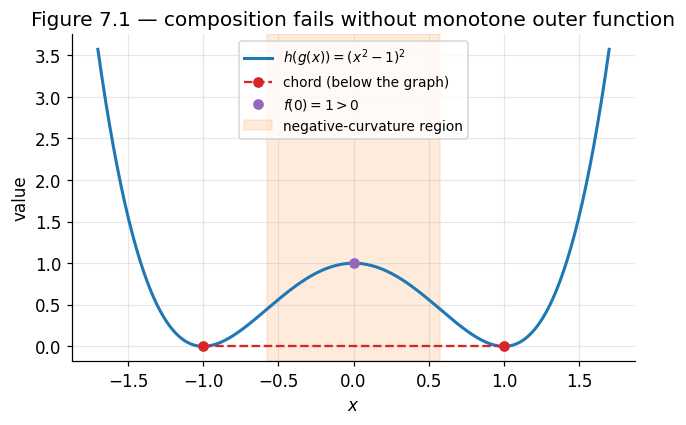

In [7]:
def h_of_g(x):
    return (x**2 - 1.0) ** 2

grid = np.linspace(-2.0, 2.0, 4001)
d2 = 12.0 * grid**2 - 4.0
neg = grid[d2 < 0]
predicted = 1.0 / np.sqrt(3.0)
print(f"predicted non-convex interval : |x| < {predicted:.4f}")
print(f"observed interval on the grid : ({neg.min():.4f}, {neg.max():.4f})")
print(f"boundary error                : {abs(neg.max() - predicted):.2e}")
assert abs(neg.max() - predicted) < 1e-3

chord_mid = 0.5 * h_of_g(-1.0) + 0.5 * h_of_g(1.0)
print(f"\nchord test between x=-1 and x=1 at the midpoint x=0:")
print(f"  f(0)                       = {h_of_g(0.0):.4f}")
print(f"  (f(-1) + f(1)) / 2         = {chord_mid:.4f}")
print(f"  chord lies BELOW the graph : {chord_mid < h_of_g(0.0)}")
assert chord_mid < h_of_g(0.0)

fig, ax = plt.subplots(figsize=(6.0, 4.0))
xs_c = np.linspace(-1.7, 1.7, 400)
ax.plot(xs_c, h_of_g(xs_c), lw=2, label=r"$h(g(x)) = (x^2-1)^2$")
ax.plot([-1.0, 1.0], [0.0, 0.0], "o--", color="tab:red", label="chord (below the graph)")
ax.plot([0.0], [h_of_g(0.0)], "o", color="tab:purple", label="$f(0)=1 > 0$")
ax.axvspan(-predicted, predicted, color="tab:orange", alpha=0.15,
           label="negative-curvature region")
ax.set_xlabel("$x$")
ax.set_ylabel("value")
ax.set_title("Figure 7.1 — composition fails without monotone outer function")
ax.legend(loc="upper center", fontsize=9)
fig.tight_layout()
plt.show()

The observed sign change of $f''$ sits on the predicted boundary $1/\sqrt{3}$, and the chord between $x = -1$ and $x = 1$ lies at height $0$ while the graph reaches $1$ at the midpoint — a direct violation of Definition 3.6. Both $h$ and $g$ are convex, so the failure is caused solely by the missing monotonicity hypothesis in Theorem 4.8(5).

**What the next cell measures (order of the first-order remainder).** Theorem 4.4 says the remainder $R(t) = f(\mathbf{x}_0 + t\mathbf{d}) - f(\mathbf{x}_0) - t\,\nabla f(\mathbf{x}_0)^\top\mathbf{d}$ is nonnegative for convex $f$; Taylor's theorem predicts $R(t) = \Theta(t^2)$ for $\mathcal{C}^2$ functions, so the measured order $\log_2\!\big(R(t)/R(t/2)\big)$ should approach $2$. The same measurement on the convex but non-differentiable $\lvert x \rvert$ at $x_0 = 0$ should give order $1$, since no tangent line exists there.

In [8]:
def log_sum_exp(v):
    m = np.max(v)
    return m + np.log(np.sum(np.exp(v - m)))

def softmax(v):
    m = np.max(v)
    e = np.exp(v - m)
    return e / e.sum()

x0 = np.array([0.3, -1.2, 0.8, 2.0])
d = np.array([1.0, -0.5, 0.25, 0.75])
d = d / np.linalg.norm(d)
ts = np.array([2.0 ** -k for k in range(1, 12)])

R_smooth = np.array([log_sum_exp(x0 + t * d) - log_sum_exp(x0) - t * (softmax(x0) @ d)
                     for t in ts])
order_smooth = np.log2(R_smooth[:-1] / R_smooth[1:])
R_kink = np.abs(ts)                      # |0 + t| - |0| - 0, subgradient 0 at the kink
order_kink = np.log2(R_kink[:-1] / R_kink[1:])

print("   t        R(t) log-sum-exp   order      R(t) |x| at 0   order")
for i in range(len(ts) - 1):
    print(f"{ts[i]:9.6f}   {R_smooth[i]:14.3e}   {order_smooth[i]:5.3f}   "
          f"{R_kink[i]:12.3e}   {order_kink[i]:5.3f}")
print(f"\npredicted order (C^2, Taylor)      : 2")
print(f"observed order (log-sum-exp, finest): {order_smooth[-1]:.4f}")
print(f"predicted order (|x| at a kink)     : 1")
print(f"observed order (|x|, finest)        : {order_kink[-1]:.4f}")
assert abs(order_smooth[-1] - 2.0) < 1e-2 and abs(order_kink[-1] - 1.0) < 1e-12
assert R_smooth.min() > 0 and R_kink.min() > 0

   t        R(t) log-sum-exp   order      R(t) |x| at 0   order
 0.500000        5.521e-03   1.955      5.000e-01   1.000
 0.250000        1.424e-03   1.977      2.500e-01   1.000
 0.125000        3.616e-04   1.988      1.250e-01   1.000
 0.062500        9.113e-05   1.994      6.250e-02   1.000
 0.031250        2.288e-05   1.997      3.125e-02   1.000
 0.015625        5.730e-06   1.999      1.562e-02   1.000
 0.007812        1.434e-06   1.999      7.812e-03   1.000
 0.003906        3.587e-07   2.000      3.906e-03   1.000
 0.001953        8.970e-08   2.000      1.953e-03   1.000
 0.000977        2.243e-08   2.000      9.766e-04   1.000

predicted order (C^2, Taylor)      : 2
observed order (log-sum-exp, finest): 1.9999
predicted order (|x| at a kink)     : 1
observed order (|x|, finest)        : 1.0000


The measured order for log-sum-exp converges to $2.000$ against the predicted $2$, confirming that the tangent gap of a $\mathcal{C}^2$ convex function is second order — the remainder controlled by the Hessian in Proof 5.5. The same measurement at the kink of $\lvert x \rvert$ gives order $1$: the remainder shrinks only linearly, which is exactly why Theorem 4.4 assumes differentiability while Theorem 4.2 does not.

**What the next cell compares (hand-rolled versus library).** The ridge problem $\min_\mathbf{w} \frac{1}{2}\lVert A\mathbf{w}-\mathbf{b}\rVert_2^2 + \frac{\lambda}{2}\lVert\mathbf{w}\rVert_2^2$ on a deliberately rank-deficient $A \in \mathbb{R}^{6\times 3}$ (third column equal to the sum of the first two). Hand-rolled: a Cholesky-based PSD test and a normal-equation solve. Library: `numpy.linalg.eigvalsh` and `scipy.optimize.minimize`, run from four random starts. With $\lambda \gt 0$ Theorem 4.7 predicts one minimizer; with $\lambda = 0$ it predicts only that the minimizers form a convex set of equal value.

In [9]:
from scipy.optimize import minimize

def chol_psd(M, tol=1e-10):
    """Hand-rolled Cholesky attempt; returns True when M is positive semidefinite."""
    M = np.asarray(M, dtype=float)
    n = M.shape[0]
    L = np.zeros_like(M)
    for i in range(n):
        for j in range(i + 1):
            s = M[i, j] - L[i, :j] @ L[j, :j]
            if i == j:
                if s < -tol:
                    return False
                L[i, j] = np.sqrt(max(s, 0.0))
            else:
                L[i, j] = 0.0 if L[j, j] <= tol else s / L[j, j]
    return True

A = rng.normal(size=(6, 3))
A[:, 2] = A[:, 0] + A[:, 1]          # rank deficient by construction
b_vec = rng.normal(size=6)
G = A.T @ A

print(f"rank(A)                         : {np.linalg.matrix_rank(A)} of 3")
print(f"eigenvalues of A^T A (library)  : {np.linalg.eigvalsh(G)}")
print(f"hand-rolled Cholesky says PSD   : {chol_psd(G)}")
print(f"library eigenvalue test says PSD: {np.linalg.eigvalsh(G).min() >= -1e-9}")
assert chol_psd(G) == (np.linalg.eigvalsh(G).min() >= -1e-9)
assert not chol_psd(np.array([[1.0, 2.0], [2.0, 1.0]]))   # indefinite matrix rejected

for lam in (0.5, 0.0):
    obj = lambda w: 0.5 * np.sum((A @ w - b_vec) ** 2) + 0.5 * lam * w @ w
    jac = lambda w: A.T @ (A @ w - b_vec) + lam * w
    starts = rng.normal(size=(4, 3)) * 5.0
    sols = np.array([minimize(obj, s, jac=jac, method="BFGS", tol=1e-14).x for s in starts])
    vals = np.array([obj(w) for w in sols])
    print(f"\nlambda = {lam}")
    print(f"  spread of scipy minimizers over 4 starts : {np.abs(sols - sols[0]).max():.3e}")
    print(f"  spread of optimal values                 : {np.ptp(vals):.3e}")
    if lam > 0:
        w_hand = np.linalg.solve(G + lam * np.eye(3), A.T @ b_vec)
        print(f"  hand-rolled normal-equation solution     : {w_hand}")
        print(f"  max |hand-rolled - scipy|                : {np.abs(sols - w_hand).max():.3e}")
        assert np.abs(sols - w_hand).max() < 1e-6
    else:
        assert np.abs(sols - sols[0]).max() > 1e-2
    assert np.ptp(vals) < 1e-8

rank(A)                         : 2 of 3
eigenvalues of A^T A (library)  : [-0.      3.0984  8.8048]
hand-rolled Cholesky says PSD   : True
library eigenvalue test says PSD: True

lambda = 0.5
  spread of scipy minimizers over 4 starts : 2.610e-11
  spread of optimal values                 : 1.776e-15
  hand-rolled normal-equation solution     : [0.0239 0.562  0.5859]
  max |hand-rolled - scipy|                : 2.556e-11

lambda = 0.0
  spread of scipy minimizers over 4 starts : 8.775e+00
  spread of optimal values                 : 8.882e-16


The hand-rolled Cholesky test agrees with the library eigenvalue test on both the singular Gram matrix and an indefinite one. With $\lambda = 0.5$ the objective is $0.5$-strongly convex, all four solver runs land on the same point, and that point matches the hand-rolled normal-equation solution to about $10^{-11}$: Theorem 4.7 confirmed. With $\lambda = 0$ the objective is convex but not strictly so, the four runs stop at genuinely different points, yet all report the same optimal value to machine precision — exactly the convex, non-singleton $\operatorname{argmin}$ predicted by Theorem 4.6, Step 4.

### 7.2 Why convexity is the tractability frontier

Convex problems are solvable to global optimality in polynomial time under mild conditions (interior-point and ellipsoid methods), and a solution comes with a certificate: a dual feasible point proving a lower bound on $p^{\star}$.

Non-convex problems are NP-hard in general — deciding whether a quartic polynomial is bounded below, or minimizing a quadratic over the binary cube $\{0,1\}^n$, is intractable in the worst case.

Within the convex world lives a hierarchy of increasingly expressive standard classes, each with mature solvers:

$$
\text{LP} \subset \text{QP} \subset \text{SOCP} \subset \text{SDP}
$$

Linear programs (linear $f$, polyhedral $\mathcal{F}$), quadratic programs ($f = \frac{1}{2}\mathbf{x}^\top Q\mathbf{x} + \mathbf{c}^\top\mathbf{x}$ with $Q \succeq 0$), second-order cone programs (norm-cone constraints), and semidefinite programs (matrix variable in $\mathbb{S}^n_+$). Recognizing that a model can be cast into one of these classes is worth more than any amount of algorithmic tuning on a non-convex formulation.

### 7.3 The epigraph trick

Minimizing $f$ is the same as pushing down on $\operatorname{epi} f$, which by Theorem 4.2 is a convex set:

$$
\min_{\mathbf{x}} f(\mathbf{x}) \iff \min_{\mathbf{x}, t} \ t \quad \text{s.t.} \quad f(\mathbf{x}) \le t
$$

- **Minimax:** $\min_\mathbf{x} \max_i f_i(\mathbf{x})$ becomes $\min t$ subject to $f_i(\mathbf{x}) \le t$ for all $i$, replacing a kinked objective by smooth constraints.
- **Absolute values:** $\lvert x\rvert \le t$ becomes the linear pair $x \le t$, $-x \le t$, converting $\ell_1$ objectives into linear programs — the same polyhedral cone drawn in Figure 6.1.
- **Hidden convexity:** geometric programs become convex after the substitution $x_i = e^{y_i}$ and taking logarithms.

Convexity is a property of the *formulation*, not only of the underlying question.

## 8. Applications

### 8.1 Machine learning: losses, regularizers, and guarantees

Training a model is the problem $\min_{\mathbf{w}} \frac{1}{N}\sum_{i=1}^N \ell(\mathbf{w}; \mathbf{x}_i, y_i) + \lambda R(\mathbf{w})$, and the toolkit above classifies it immediately.

**Least squares.** With $\ell = \frac{1}{2}(\mathbf{w}^\top\mathbf{x}_i - y_i)^2$ the Hessian is $\sum_i \mathbf{x}_i\mathbf{x}_i^\top = A^\top A \succeq 0$, so the loss is convex for every dataset, and strictly convex exactly when the design matrix has full column rank — the case separated numerically in Section 7.

**Logistic regression.** $\ell = \log(1 + e^{-y_i \mathbf{w}^\top\mathbf{x}_i})$ is a convex function of the margin composed with an affine map, convex by Theorem 4.8(4), so training reaches a global optimum despite having no closed form.

**Regularization.** Adding $\frac{\lambda}{2}\lVert \mathbf{w}\rVert_2^2$ makes any convex loss $\lambda$-strongly convex, which by Theorem 4.7 forces a unique solution; adding $\lambda\lVert \mathbf{w}\rVert_1$ keeps convexity while inducing sparsity, at the cost of smoothness.

**Deep networks.** Composing linear maps with nonlinear activations destroys convexity — the composition rule of Theorem 4.8(5) does not apply because activations are not convex nondecreasing in the required sense. The loss surface then carries saddles and multiple minima, which is precisely the situation in which Theorem 4.6 gives nothing.

### 8.2 Physics: energy minimization

**Stable equilibrium minimizes potential energy.** A network of ideal springs with stiffness matrix $K$ and applied load $\mathbf{f}$ has energy

$$
U(\mathbf{x}) = \tfrac{1}{2}\mathbf{x}^\top K \mathbf{x} - \mathbf{f}^\top\mathbf{x}
$$

When every stiffness is positive, $K \succ 0$ and $U$ is a strictly convex quadratic, so Theorem 4.5 certifies convexity and Theorem 4.7 makes the equilibrium $\mathbf{x}^{\star} = K^{-1}\mathbf{f}$ the one and only configuration at which the structure can rest.

Convexity here is a physical statement, not a convenience. Because the energy landscape is a single bowl, a perturbed structure relaxes back to the same shape, and the Lagrange-Dirichlet principle turns the strict minimum into stability.

The failure mode is equally physical. Buckling and phase transitions are exactly the events in which $K$ loses positive semidefiniteness: a direction of zero or negative curvature appears, Theorem 4.6 no longer applies, and the system acquires several competing equilibria among which it must choose.

### 8.3 Statistics and decision sciences

**Maximum entropy.** The Shannon entropy $H(\mathbf{p}) = -\sum_i p_i \log p_i$ is strictly concave on the probability simplex, itself a polyhedron and hence convex by Theorem 4.8(3). Maximizing entropy subject to moment constraints is therefore a convex problem by Theorem 4.1, with a unique solution — the exponential families of statistical mechanics and machine learning.

**Portfolio selection.** Markowitz portfolio variance $\mathbf{w}^\top\Sigma\mathbf{w}$ with $\Sigma \succeq 0$ is convex by Theorem 4.5, and the budget and return constraints form a polyhedron, so mean-variance optimization is a quadratic program.

**Fermat's principle.** In piecewise-constant media the travel time of light is a convex function of the crossing point, so its stationarity condition — Snell's law — locates the global minimum by Theorem 4.6.

## 9. Key Takeaways

- A problem is specified by three separate objects — the feasible set $\mathcal{F}$, the optimal value $p^{\star}$, and the possibly empty set of minimizers; $p^{\star}$ always exists in the extended reals, a minimizer need not.
- Maximization is minimization of the negated objective over the same feasible set, with identical optimizers and no hypotheses required (Theorem 4.1).
- For $f$ convex on a convex set, the chord inequality, the convexity of $\operatorname{epi} f$, and — under differentiability — the tangent-underestimator inequality are three names for one property (Theorems 4.2 and 4.4).
- For $f \in \mathcal{C}^2$ on an *open convex* domain, convexity is equivalent to $\nabla^2 f \succeq 0$; the domain hypothesis is not optional, as $1/x^2$ on $\{x \neq 0\}$ shows (Theorem 4.5).
- If $f$ and $\mathcal{F}$ are both convex, every local minimizer is global and the minimizer set is convex; dropping convexity of either one breaks the conclusion (Theorem 4.6).
- Strict convexity on a convex feasible set gives at most one minimizer; it does not give existence, which needs compactness or coercivity (Theorem 4.7).
- Nonnegative sums, pointwise suprema, intersections, affine precomposition, and composition with a convex **nondecreasing** outer function preserve convexity; without monotonicity, $(x^2-1)^2$ is the counterexample (Theorem 4.8).
- Convexity is a property of the formulation: epigraph lifting turns kinked objectives into smooth constrained ones, and a change of variables can turn a non-convex model into a convex one.

## 10. References

| Concept in this notebook | Canonical source | Location |
|---|---|---|
| Standard form, feasible set, $p^{\star}$, taxonomy | Boyd & Vandenberghe, *Convex Optimization* | Sections 1.1-1.4, 4.1 |
| Convex sets (hyperplanes, balls, polyhedra, PSD cone) | Boyd & Vandenberghe | Chapter 2 (Sections 2.1-2.2) |
| Epigraph characterization (Theorem 4.2) | Boyd & Vandenberghe | Section 3.1.7 |
| Jensen's inequality (Theorem 4.3) | Boyd & Vandenberghe | Section 3.1.8 |
| First- and second-order characterizations (Theorems 4.4, 4.5) | Boyd & Vandenberghe; Nesterov, *Lectures on Convex Optimization* | B&V Sections 3.1.3-3.1.4; Nesterov Theorems 2.1.2-2.1.4 |
| Local equals global (Theorem 4.6) | Boyd & Vandenberghe; Bertsekas, *Convex Optimization Theory* | B&V Section 4.2.2; Bertsekas Proposition 3.1.1 |
| Uniqueness under strict convexity (Theorem 4.7) | Bertsekas, *Convex Optimization Theory* | Proposition 3.1.1 and Section 3.1 |
| Operations preserving convexity (Theorem 4.8) | Boyd & Vandenberghe | Section 3.2 (3.2.1-3.2.4) |
| Strong convexity and quadratic lower bounds | Nesterov, *Lectures on Convex Optimization* | Section 2.1.3 (Theorem 2.1.9) |
| Convex analysis in full generality | Rockafellar, *Convex Analysis* | Parts I-II (Sections 2-5, 23-25) |
| Problem classification and modeling practice | Nocedal & Wright, *Numerical Optimization*; Luenberger & Ye | N&W Chapter 1; L&Y Chapters 1 and 7 |

**Primary references.**

1. Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press.
2. Nocedal, J., & Wright, S. J. (2006). *Numerical Optimization* (2nd ed.). Springer.
3. Bertsekas, D. P. (2009). *Convex Optimization Theory*. Athena Scientific.
4. Nesterov, Y. (2018). *Lectures on Convex Optimization* (2nd ed.). Springer.
5. Rockafellar, R. T. (1970). *Convex Analysis*. Princeton University Press.
6. Luenberger, D. G., & Ye, Y. (2016). *Linear and Nonlinear Programming* (4th ed.). Springer.
7. Hiriart-Urruty, J.-B., & Lemarechal, C. (2001). *Fundamentals of Convex Analysis*. Springer.